In [13]:
import argparse
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch


def plot_wind_distribution(directory: str, sample_size: int = 100000):
    """
    Recursively finds *WIND*.pkl files in a directory, collects wind data,
    and plots a histogram of the wind distribution.

    Args:
        directory (str): The path to the directory to search.
        sample_size (int): The number of data points to sample for plotting if the
                           total number of values is large.
    """
    print(f"Searching for WIND*.pt files in '{directory}'...")
    wind_files = list(Path(directory).rglob("WIND*.pt"))
    print(f"Found {len(wind_files)} wind data files.")

    if not wind_files:
        print("No WIND*.pt files found.")
        return

    all_wind_values = []
    for file_path in wind_files:
        try:
            data = torch.load(file_path)

            if isinstance(data, torch.Tensor):
                values = data.cpu().detach().numpy().flatten()
            elif isinstance(data, np.ndarray):
                values = data.flatten()
            elif isinstance(data, list):
                values = np.array(data).flatten()
            else:
                print(
                    f"Warning: Don't know how to handle data of type {type(data)} in {file_path}. Skipping."
                )
                continue

            all_wind_values.extend(values)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

    if not all_wind_values:
        print("No wind data collected.")
        return

    all_wind_values = np.array(all_wind_values)
    print(f"Collected {len(all_wind_values)} total wind values.")

    # Print mean and std
    mean_val = np.mean(all_wind_values)
    std_val = np.std(all_wind_values)
    print(f"Mean: {mean_val:.3f}, Std: {std_val:.3f}")

    if len(all_wind_values) > sample_size:
        print(f"Sampling {sample_size} values for plotting.")
        plot_data = np.random.choice(
            all_wind_values, size=sample_size, replace=False
        )
    else:
        plot_data = all_wind_values

    # Plotting
    plt.figure(figsize=(10, 6))
    sns.set_style("ticks")
    sns.histplot(plot_data, kde=True, bins=50, stat="density")
    plt.title("Distribution of Average Tailwind")
    plt.xlabel("Tailwind (knots)")
    plt.ylabel("Density")
    plt.show()


Searching for WIND*.pt files in '../data/cases/LEMD_EGLL_Working1/tres_runs'...
Found 314 wind data files.
Collected 3402966 total wind values.
Mean: -19.457, Std: 33.787
Sampling 100000 values for plotting.


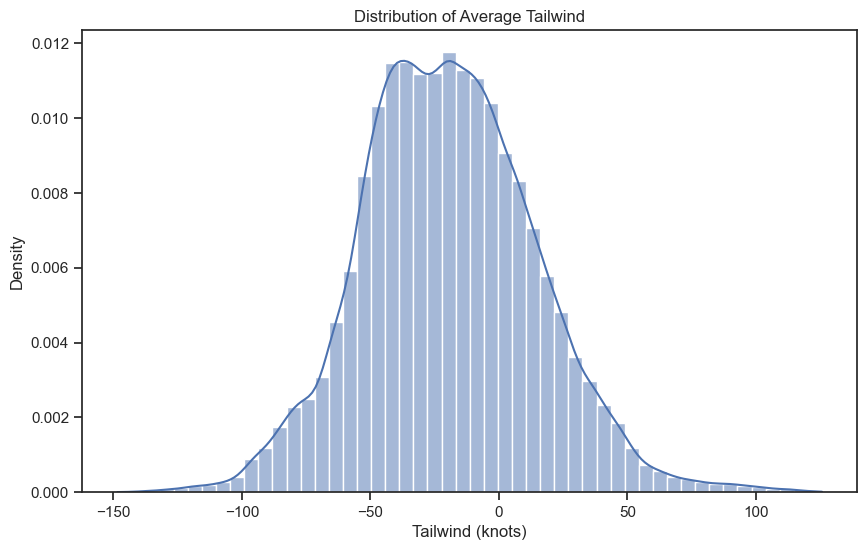

In [14]:
plot_wind_distribution("../data/cases/LEMD_EGLL_Working1/tres_runs", 100000)